<a href="https://colab.research.google.com/github/AliceNanL/BA820-project/blob/Cat_dataset_EDA_Stephanie/BA820_Cats_EDA_Stephanie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###UK Pet Cats GPS Tracking Data

1 - Domain
*   UK pet cat mobility dataset based on GPS tracking.
*   Goal: understand how domestic cats roam and move in the real world (unlabeled behavior traces).

2 - What it represents

(1) cats (event-level table)

*   Each row = one timestamped GPS ping for a cat

*   Includes latitude/longitude + data-quality flags (e.g., visible, outlier markers)

(2) cats_ref (cat-level reference table)

*   Each row = one cat (matched by tag_id)

*   Includes metadata such as sex, age, indoor hours, household context (e.g., number of cats), and hunting-related fields

3 - Data types included

*   Time series: timestamp (sequential pings)

*   Geospatial: location_lat, location_long

*   Categorical: visible, outlier flags, sex, hunting indicators, reproductive condition, food categories

*   Numeric: age, hours indoors, prey per month, household counts

4 - Approximate size & structure

*   Roughly 18,000 of GPS events in cats

*   Around ~100 cats in cats_ref

*   Structure is one-to-many: 1 cat → many GPS pings

5 - Stakeholders

*   Wildlife/ecology researchers: roaming patterns & potential predation impact

*   Animal welfare / NGOs: balancing outdoor access with safety and welfare

*   Local policy makers: evidence for community guidance or interventions

*   Cat owners / vets: understanding risk patterns and individual differences

6 - Why it’s interesting

It’s unlabeled real-world behavior to discover

*   natural mobility segments (e.g., home-body vs explorer)

*   similarity between cats’ roaming behaviors

*   extreme roaming cases

# **Data Loading**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
cats = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-01-31/cats_uk.csv')
cats_ref = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-01-31/cats_uk_reference.csv')

# **Data Cleaning**

**Check the `cats` dataset**

In [ ]:
cats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18215 entries, 0 to 18214
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   tag_id                    18215 non-null  object 
 1   event_id                  18215 non-null  int64  
 2   visible                   18215 non-null  bool   
 3   timestamp                 18215 non-null  object 
 4   location_long             18215 non-null  float64
 5   location_lat              18215 non-null  float64
 6   ground_speed              18215 non-null  int64  
 7   height_above_ellipsoid    18215 non-null  float64
 8   algorithm_marked_outlier  18215 non-null  bool   
 9   manually_marked_outlier   18215 non-null  bool   
 10  study_name                18215 non-null  object 
dtypes: bool(3), float64(3), int64(2), object(3)
memory usage: 1.2+ MB


In [ ]:
cats.head(5)

,tag_id,event_id,visible,timestamp,location_long,location_lat,ground_speed,height_above_ellipsoid,algorithm_marked_outlier,manually_marked_outlier,study_name
0,Ares,3395610551,True,2017-06-24T01:03:57Z,-5.113851,50.170315,684,154.67,False,False,Pet Cats United Kingdom
1,Ares,3395610552,True,2017-06-24T01:11:20Z,-5.113851,50.170315,936,154.67,False,False,Pet Cats United Kingdom
2,Ares,3395610553,True,2017-06-24T02:58:16Z,-5.113730,50.169876,2340,81.35,False,False,Pet Cats United Kingdom
3,Ares,3395610554,True,2017-06-24T03:01:26Z,-5.113774,50.169827,0,67.82,False,False,Pet Cats United Kingdom
4,Ares,3395610555,True,2017-06-24T03:51:58Z,-5.114247,50.170139,4896,118.03,False,False,Pet Cats United Kingdom


In [ ]:
#Check the type of value in tag_id column
cats["tag_id"].value_counts()

,count
tag_id,
Gracie_2-Tag,963
Bits-Tag,867
Teddy-Tag,791
Ginge-Tag,445
Maxwell-Tag,404
...,...
Felix-Tag,51
Tigger-Tag,51
Lily-Tag,46


In [ ]:
# Check if there are duplicates in tag_id, event_id,study_name in the dataset cats
print("Number of unique tag_id: {}".format(cats["tag_id"].nunique()))
print("Number of unique event_id: {}".format(cats["event_id"].nunique()))
print("Number of unique study_name: {}".format(cats["study_name"].nunique()))

Number of unique tag_id: 101
Number of unique event_id: 18215
Number of unique study_name: 1


In [ ]:
# We would like to keep the tag_id format consistent
cats["tag_id"] = cats["tag_id"].str.replace("-Tag", "", regex=False)
cats["tag_id"]

,tag_id
0,Ares
1,Ares
2,Ares
3,Ares
4,Ares
...,...
18210,Millie
18211,Millie
18212,Millie
18213,Millie


In [ ]:
cats["tag_id"].value_counts()

,count
tag_id,
Gracie_2,963
Bits,867
Teddy,791
Ginge,445
Maxwell,404
...,...
Felix,51
Tigger,51
Lily,46


In [ ]:
# Drop the study_name column in the cats dataset
cats = cats.drop(columns=["study_name"])
cats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18215 entries, 0 to 18214
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   tag_id                    18215 non-null  object 
 1   event_id                  18215 non-null  int64  
 2   visible                   18215 non-null  bool   
 3   timestamp                 18215 non-null  object 
 4   location_long             18215 non-null  float64
 5   location_lat              18215 non-null  float64
 6   ground_speed              18215 non-null  int64  
 7   height_above_ellipsoid    18215 non-null  float64
 8   algorithm_marked_outlier  18215 non-null  bool   
 9   manually_marked_outlier   18215 non-null  bool   
dtypes: bool(3), float64(3), int64(2), object(2)
memory usage: 1.0+ MB


**Check the `cats_reference` dataset**

In [ ]:
cats_ref.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tag_id                         101 non-null    object 
 1   animal_id                      101 non-null    object 
 2   animal_taxon                   101 non-null    object 
 3   deploy_on_date                 101 non-null    object 
 4   deploy_off_date                101 non-null    object 
 5   hunt                           92 non-null     object 
 6   prey_p_month                   101 non-null    float64
 7   animal_reproductive_condition  98 non-null     object 
 8   animal_sex                     101 non-null    object 
 9   hrs_indoors                    101 non-null    float64
 10  n_cats                         101 non-null    int64  
 11  food_dry                       101 non-null    bool   
 12  food_wet                       101 non-null    boo

In [ ]:
# 1) Missingness + data quality flags
missing_cats = (cats.isna().mean().sort_values(ascending=False) * 100).round(2)
missing_ref = (cats_ref.isna().mean().sort_values(ascending=False) * 100).round(2)

print("Missingness (%) - cats (top 10):\n{}".format(missing_cats.head(10)))
print("\nMissingness (%) - cats_ref (top 10):\n{}".format(missing_ref.head(10)))

for col in ["visible", "algorithm_marked_outlier", "manually_marked_outlier"]:
    if col in cats.columns:
        print("\n{} value counts:\n{}".format(col, cats[col].value_counts(dropna=False)))


Missingness (%) - cats (top 10):
tag_id                      0.0
event_id                    0.0
visible                     0.0
timestamp                   0.0
location_long               0.0
location_lat                0.0
ground_speed                0.0
height_above_ellipsoid      0.0
algorithm_marked_outlier    0.0
manually_marked_outlier     0.0
dtype: float64

Missingness (%) - cats_ref (top 10):
food_other                       9.90
hunt                             8.91
animal_reproductive_condition    2.97
age_years                        0.99
deploy_on_date                   0.00
animal_taxon                     0.00
tag_id                           0.00
animal_id                        0.00
prey_p_month                     0.00
deploy_off_date                  0.00
dtype: float64

visible value counts:
visible
True     17866
False      349
Name: count, dtype: int64

algorithm_marked_outlier value counts:
algorithm_marked_outlier
False    18004
True       211
Name: count, dtyp

In [ ]:
cats_ref.head(5)

,tag_id,animal_id,animal_taxon,deploy_on_date,deploy_off_date,hunt,prey_p_month,animal_reproductive_condition,animal_sex,hrs_indoors,n_cats,food_dry,food_wet,food_other,study_site,age_years
0,Tommy-Tag,Tommy,Felis catus,2017-06-03T01:02:09Z,2017-06-10T02:10:52Z,True,12.5,Neutered,m,12.5,2,True,True,False,UK,11.0
1,Athena,Athena,Felis catus,2017-06-24T01:02:13Z,2017-06-30T23:59:32Z,True,3.0,Spayed,f,7.5,2,True,True,False,UK,3.0
2,Ares,Ares,Felis catus,2017-06-24T01:03:57Z,2017-06-30T23:58:01Z,NaN,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
3,Lola,Lola,Felis catus,2017-06-24T01:18:49Z,2017-06-30T09:04:40Z,True,3.0,Spayed,f,17.5,1,True,True,False,UK,10.0
4,Maverick,Maverick,Felis catus,2017-06-25T01:04:35Z,2017-07-03T09:10:07Z,True,3.0,Neutered,m,12.5,1,True,True,True,UK,7.0


In [ ]:
# Check if there are duplicates in tag_id,animal_id, animal_taxon,animal_reproductive_condition, study_site in dataset cats_ref
print("Number of unique tag_id: {}".format(cats_ref["tag_id"].nunique()))
print("Number of unique animal_id: {}".format(cats_ref["animal_id"].nunique()))
print("Number of unique animal_taxon: {}".format(cats_ref["animal_taxon"].nunique()))
print("Number of unique animal_reproductive_condition: {}".format(cats_ref["animal_reproductive_condition"].nunique()))
print("Number of unique study_site: {}".format(cats_ref["study_site"].nunique()))

Number of unique tag_id: 101
Number of unique animal_id: 101
Number of unique animal_taxon: 1
Number of unique animal_reproductive_condition: 3
Number of unique study_site: 1


In [ ]:
# Drop the columns: animal_taxon,study_site
cats_ref = cats_ref.drop(columns=["animal_taxon","study_site"])


In [ ]:
#Check the types of values in animal_reprodcutive_taxon column
cats_ref["animal_reproductive_condition"].value_counts()


,count
animal_reproductive_condition,
Neutered,55
Spayed,41
Not fixed,2


In [ ]:
# in dataset cats_ref, get the rows where animal_reproduction_condition is neutered and animal_sex is f
label_error_m = cats_ref[(cats_ref["animal_reproductive_condition"] == "spayed") & (cats_ref["animal_sex"] == "m")]
label_error_f = cats_ref[(cats_ref["animal_reproductive_condition"] == "neutered") & (cats_ref["animal_sex"] == "f")]
print("Number of rows with label error for reproductive condition: {}".format(len(label_error_m) + len(label_error_f)))



Number of rows with label error for reproductive condition: 0


In [ ]:
cats_ref.loc[(cats_ref["animal_reproductive_condition"] == "Spayed") | (cats_ref["animal_reproductive_condition"] == "Neutered"), "animal_reproductive_condition"] = "Fixed"
cats_ref["animal_reproductive_condition"].value_counts()

,count
animal_reproductive_condition,
Fixed,96
Not fixed,2


In [ ]:
# Imputation on cats_ref: food_other, hunt, animal_reproductive_condition, age_years
# We inspect the distribution of these categorical variables with missing values
print("Hunt distribution:\n", cats_ref["hunt"].value_counts(dropna=False))
print("\nFood_other distribution:\n", cats_ref["food_other"].value_counts(dropna=False))
print("\nAnimal reproductive condition distribution:\n", cats_ref["animal_reproductive_condition"].value_counts(dropna=False))

Hunt distribution:
 hunt
True     81
False    11
NaN       9
Name: count, dtype: int64

Food_other distribution:
 food_other
False    49
True     42
NaN      10
Name: count, dtype: int64

Animal reproductive condition distribution:
 animal_reproductive_condition
Fixed        96
NaN           3
Not fixed     2
Name: count, dtype: int64


In [ ]:
# Impute the missing values of categorical variables by mode
cats_ref["hunt"].fillna(cats_ref["hunt"].mode()[0], inplace=True)
cats_ref["food_other"].fillna(cats_ref["food_other"].mode()[0], inplace=True)
cats_ref["animal_reproductive_condition"].fillna(cats_ref["animal_reproductive_condition"].mode()[0], inplace=True)

/tmp/ipython-input-4164074091.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cats_ref["hunt"].fillna(cats_ref["hunt"].mode()[0], inplace=True)
/tmp/ipython-input-4164074091.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cats_ref["hunt"].fillna(cats_ref["hunt"].mode()[0], inplace=True)
/tmp/ipython-inp

In [ ]:
# Impute the age_years by median
cats_ref["age_years"].fillna(cats_ref["age_years"].median(), inplace=True)


/tmp/ipython-input-3458866140.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cats_ref["age_years"].fillna(cats_ref["age_years"].median(), inplace=True)


In [ ]:
cats_ref.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tag_id                         101 non-null    object 
 1   animal_id                      101 non-null    object 
 2   deploy_on_date                 101 non-null    object 
 3   deploy_off_date                101 non-null    object 
 4   hunt                           101 non-null    bool   
 5   prey_p_month                   101 non-null    float64
 6   animal_reproductive_condition  101 non-null    object 
 7   animal_sex                     101 non-null    object 
 8   hrs_indoors                    101 non-null    float64
 9   n_cats                         101 non-null    int64  
 10  food_dry                       101 non-null    bool   
 11  food_wet                       101 non-null    bool   
 12  food_other                     101 non-null    boo

In [ ]:
cats_ref.head(15)

,tag_id,animal_id,deploy_on_date,deploy_off_date,hunt,prey_p_month,animal_reproductive_condition,animal_sex,hrs_indoors,n_cats,food_dry,food_wet,food_other,age_years
0,Tommy-Tag,Tommy,2017-06-03T01:02:09Z,2017-06-10T02:10:52Z,True,12.5,Fixed,m,12.5,2,True,True,False,11.0
1,Athena,Athena,2017-06-24T01:02:13Z,2017-06-30T23:59:32Z,True,3.0,Fixed,f,7.5,2,True,True,False,3.0
2,Ares,Ares,2017-06-24T01:03:57Z,2017-06-30T23:58:01Z,True,0.0,Fixed,m,7.5,2,True,True,False,3.0
3,Lola,Lola,2017-06-24T01:18:49Z,2017-06-30T09:04:40Z,True,3.0,Fixed,f,17.5,1,True,True,False,10.0
4,Maverick,Maverick,2017-06-25T01:04:35Z,2017-07-03T09:10:07Z,True,3.0,Fixed,m,12.5,1,True,True,True,7.0
5,Coco,Coco,2017-06-28T01:02:22Z,2017-07-05T06:50:04Z,True,3.0,Fixed,f,12.5,2,True,True,True,7.0
6,Charlie,Charlie,2017-06-28T01:03:33Z,2017-07-04T07:08:31Z,True,3.0,Fixed,m,12.5,3,True,True,False,6.0
7,Jago,Jago,2017-06-28T04:10:59Z,2017-07-04T02:50:05Z,True,17.5,Fixed,m,7.5,4,True,True,True,2.0
8,Morpheus-Tag,Morpheus,2017-07-01T01:02:18Z,2017-07-09T06:39:05Z,True,3.0,Fixed,m,2.5,2,True,False,False,4.0
9,Nettle-Tag,Nettle,2017-07-01T01:05:50Z,2017-07-08T00:05:12Z,True,7.5,Fixed,f,12.5,2,True,False,False,4.0


In [ ]:
# Check if the values of tag_id matches the corresponding value of animal_id in each row
print("Number of rows where tag_id does not match animal_id: {}".format(len(cats_ref[cats_ref["tag_id"] != cats_ref["animal_id"]])))
#slice the dataset where the values of tag_id matches the corresponding value of animal_id in each row
cats_ref_sub = cats_ref[cats_ref["tag_id"] != cats_ref["animal_id"]]
cats_ref_sub

Number of rows where tag_id does not match animal_id: 93


,tag_id,animal_id,deploy_on_date,deploy_off_date,hunt,prey_p_month,animal_reproductive_condition,animal_sex,hrs_indoors,n_cats,food_dry,food_wet,food_other,age_years
0,Tommy-Tag,Tommy,2017-06-03T01:02:09Z,2017-06-10T02:10:52Z,True,12.5,Fixed,m,12.5,2,True,True,False,11.0
8,Morpheus-Tag,Morpheus,2017-07-01T01:02:18Z,2017-07-09T06:39:05Z,True,3.0,Fixed,m,2.5,2,True,False,False,4.0
9,Nettle-Tag,Nettle,2017-07-01T01:05:50Z,2017-07-08T00:05:12Z,True,7.5,Fixed,f,12.5,2,True,False,False,4.0
10,Meg-Tag,Meg,2017-07-02T01:02:43Z,2017-07-09T00:36:13Z,True,3.0,Fixed,f,12.5,1,True,True,True,8.0
12,Carbonel-Tag,Carbonel,2017-07-07T01:01:46Z,2017-07-14T02:51:28Z,False,0.0,Fixed,m,17.5,1,True,False,False,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,Charlie3-Tag,Charlie3,2017-11-20T01:16:41Z,2017-11-26T00:38:20Z,True,7.5,Fixed,m,12.5,2,False,True,True,5.0
97,Millie-Tag,Millie,2017-11-20T01:38:55Z,2017-11-27T00:09:29Z,True,7.5,Fixed,f,12.5,2,False,True,True,3.0
98,SmokeyLongnose-Tag,SmokeyLongnose,2017-11-20T01:47:42Z,2017-11-27T02:53:41Z,True,0.5,Fixed,f,7.5,2,True,True,True,9.0
99,CJ-Tag,CJ,2017-11-24T06:48:32Z,2017-11-29T03:44:48Z,True,0.5,Fixed,m,22.5,2,True,True,False,5.0


In [ ]:
# Check if there is any value including Tag or tag in animal_id column
print("Number of rows where animal_id contains Tag or tag: {}".format(cats_ref[cats_ref["animal_id"].str.contains("Tag|tag")].shape[0]))

Number of rows where animal_id contains Tag or tag: 0


In [ ]:
# Since tag_id and animal_id contain identical information with different formats, we only keep animal_id column
cats_ref = cats_ref.drop(columns=["tag_id"])
cats_ref.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   animal_id                      101 non-null    object 
 1   deploy_on_date                 101 non-null    object 
 2   deploy_off_date                101 non-null    object 
 3   hunt                           101 non-null    bool   
 4   prey_p_month                   101 non-null    float64
 5   animal_reproductive_condition  101 non-null    object 
 6   animal_sex                     101 non-null    object 
 7   hrs_indoors                    101 non-null    float64
 8   n_cats                         101 non-null    int64  
 9   food_dry                       101 non-null    bool   
 10  food_wet                       101 non-null    bool   
 11  food_other                     101 non-null    bool   
 12  age_years                      101 non-null    flo

In [ ]:
# Get unique values from both columns
unique_tag_ids = set(cats["tag_id"].unique())
unique_animal_ids = set(cats_ref["animal_id"].unique())

# Check if the sets are identical
if unique_tag_ids == unique_animal_ids:
    print("The unique values in 'tag_id' (cats) and 'animal_id' (cats_ref) are identical.")
else:
    print("The unique values are NOT identical. Checking for differences...")
    # Find values present in cats['tag_id'] but not in cats_ref['animal_id']
    missing_in_cats_ref = unique_tag_ids - unique_animal_ids
    if missing_in_cats_ref:
        print(f"  Values in cats['tag_id'] not found in cats_ref['animal_id']: {missing_in_cats_ref}")

    # Find values present in cats_ref['animal_id'] but not in cats['tag_id']
    missing_in_cats = unique_animal_ids - unique_tag_ids
    if missing_in_cats:
        print(f"  Values in cats_ref['animal_id'] not found in cats['tag_id']: {missing_in_cats}")

The unique values in 'tag_id' (cats) and 'animal_id' (cats_ref) are identical.


In [ ]:
# Join the two datasets
cats = cats.rename(columns={'tag_id': 'animal_id'})
cats_sum = pd.merge(cats, cats_ref, on="animal_id", how="left")
cats_sum.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18215 entries, 0 to 18214
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   animal_id                      18215 non-null  object 
 1   event_id                       18215 non-null  int64  
 2   visible                        18215 non-null  bool   
 3   timestamp                      18215 non-null  object 
 4   location_long                  18215 non-null  float64
 5   location_lat                   18215 non-null  float64
 6   ground_speed                   18215 non-null  int64  
 7   height_above_ellipsoid         18215 non-null  float64
 8   algorithm_marked_outlier       18215 non-null  bool   
 9   manually_marked_outlier        18215 non-null  bool   
 10  deploy_on_date                 18215 non-null  object 
 11  deploy_off_date                18215 non-null  object 
 12  hunt                           18215 non-null 

In [ ]:
cats_sum['visible'].value_counts()

,count
visible,
True,17866
False,349


# **EDA**

In [ ]:
# Clean GPS points to spatial analysis
gps_clean = cats_sum.copy()

# 1. Convert timestamp to datetime
gps_clean["timestamp"] = pd.to_datetime(gps_clean["timestamp"])

# 2. Keep valid coordinates only
gps_clean = gps_clean.dropna(subset=["location_lat", "location_long"])

# 3. Keep only visible points
gps_clean = gps_clean[gps_clean["visible"] == True]

# 4. Remove points flagged as outliers (algorithm or manual)
gps_clean = gps_clean[gps_clean["algorithm_marked_outlier"] == False]
gps_clean = gps_clean[gps_clean["manually_marked_outlier"] == False]

print("Rows after cleaning: {}".format(gps_clean.shape[0]))
print("Unique cats after cleaning: {}".format(gps_clean["animal_id"].nunique()))

Rows after cleaning: 17866
Unique cats after cleaning: 101


In [46]:
# Build cat_footprint

# 1. Compute a robust home location per cat using median lat/long
home = gps_clean.groupby("animal_id").agg(
    home_lat=("location_lat", "median"),
    home_long=("location_long", "median"),
    n_pings=("event_id", "count"),
    t_min=("timestamp", "min"),
    t_max=("timestamp", "max"),
    hrs_indoors=("hrs_indoors", "median"),
    n_cats=("n_cats", "median"),
    animal_sex=("animal_sex", "first"),
    age_years=("age_years", "median")
).reset_index()

# 2. Compute tracking coverage in days
home["days_covered"] = (home["t_max"] - home["t_min"]).dt.total_seconds() / (3600 * 24)

# 3. Attach home back to each ping
gps_with_home = gps_clean.merge(home[["animal_id", "home_lat", "home_long"]], on="animal_id", how="left")

# 4. Compute an approximate distance-to-home in km
#    We use a simple Euclidean distance in degrees and convert to km (~111 km per degree).
gps_with_home["dist_to_home_km"] = np.sqrt(
    (gps_with_home["location_lat"] - gps_with_home["home_lat"]) ** 2 + (gps_with_home["location_long"] - gps_with_home["home_long"]) ** 2
) * 111

# 5. Summarize roaming scale per cat using the 95th percentile distance-to-home
radius95 = gps_with_home.groupby("animal_id")["dist_to_home_km"].quantile(0.95).reset_index()
radius95 = radius95.rename(columns={"dist_to_home_km": "radius95_km"})

# 6. Final cat-level footprint table
cat_footprint = home.merge(radius95, on="animal_id", how="left")

print(cat_footprint[["radius95_km", "n_pings", "days_covered"]].describe().round(2))

       radius95_km  n_pings  days_covered
count       101.00   101.00        101.00
mean          0.19   176.89          7.02
std           0.20   144.44          3.34
min           0.04    12.00          0.51
25%           0.09    96.00          6.32
50%           0.13   155.00          6.98
75%           0.20   210.00          7.25
max           1.35   932.00         28.96


In [47]:
# Build concentrated space use for cats

# 1. Create a simple spatial grid by rounding coordinates
gps_clean["grid_lat"] = gps_clean["location_lat"].round(3)
gps_clean["grid_long"] = gps_clean["location_long"].round(3)
gps_clean["grid_cell"] = gps_clean["grid_lat"].astype(str) + "_" + gps_clean["grid_long"].astype(str)

# 2. Count how often each cat appears in each grid cell
cell_counts = gps_clean.groupby(["animal_id", "grid_cell"]).size().reset_index(name="cell_n")

# 3. Convert counts to shares p so cats with different ping counts are comparable
totals = cell_counts.groupby("animal_id")["cell_n"].sum().reset_index(name="total_n")
cell_counts = cell_counts.merge(totals, on="animal_id", how="left")
cell_counts["p"] = cell_counts["cell_n"] / cell_counts["total_n"]

# 4. Build concentration features per cat
# unique_cells: how many distinct areas visited
# top1_share: concentration in the top area
# top3_share: share explained by top 3 areas (proxy for multi-core routines)

unique_cells = cell_counts.groupby("animal_id")["grid_cell"].nunique().reset_index(name="unique_cells")
top1_share = cell_counts.groupby("animal_id")["p"].max().reset_index(name="top1_share")

top3_share = (
    cell_counts.sort_values(["animal_id", "p"], ascending=[True, False])
    .groupby("animal_id")
    .head(3)
    .groupby("animal_id")["p"]
    .sum()
    .reset_index(name="top3_share")
)

cat_conc = unique_cells.merge(top1_share, on="animal_id", how="left")
cat_conc = cat_conc.merge(top3_share, on="animal_id", how="left")

print(cat_conc[["unique_cells", "top1_share", "top3_share"]].describe().round(2))

       unique_cells  top1_share  top3_share
count        101.00      101.00      101.00
mean          10.75        0.56        0.84
std            7.23        0.19        0.14
min            3.00        0.13        0.32
25%            6.00        0.45        0.83
50%            9.00        0.54        0.88
75%           13.00        0.72        0.93
max           50.00        0.95        1.00


In [ ]:
# Build top hotspot

# 1. Summarize each grid cell by total activity and number of contributing cats
hotspot = gps_clean.groupby("grid_cell").agg(
    total_pings=("event_id", "count"),
    unique_cats=("animal_id", "nunique")
).reset_index()

# 2. Take the top 10 hotspot cells by total activity
hotspot_top = hotspot.sort_values("total_pings", ascending=False).head(10).copy()

print(hotspot_top[["grid_cell", "total_pings", "unique_cats"]])

         grid_cell  total_pings  unique_cats
362   50.21_-5.294          804            2
768  50.508_-4.921          448            3
145  50.151_-5.077          393            5
775  50.509_-4.921          366            3
81   50.145_-5.494          361            4
500  50.329_-4.769          360            1
669    50.437_-4.6          348            2
711  50.452_-4.458          328            2
414  50.237_-5.219          302            2
629   50.36_-4.758          259            3


# **Plots**

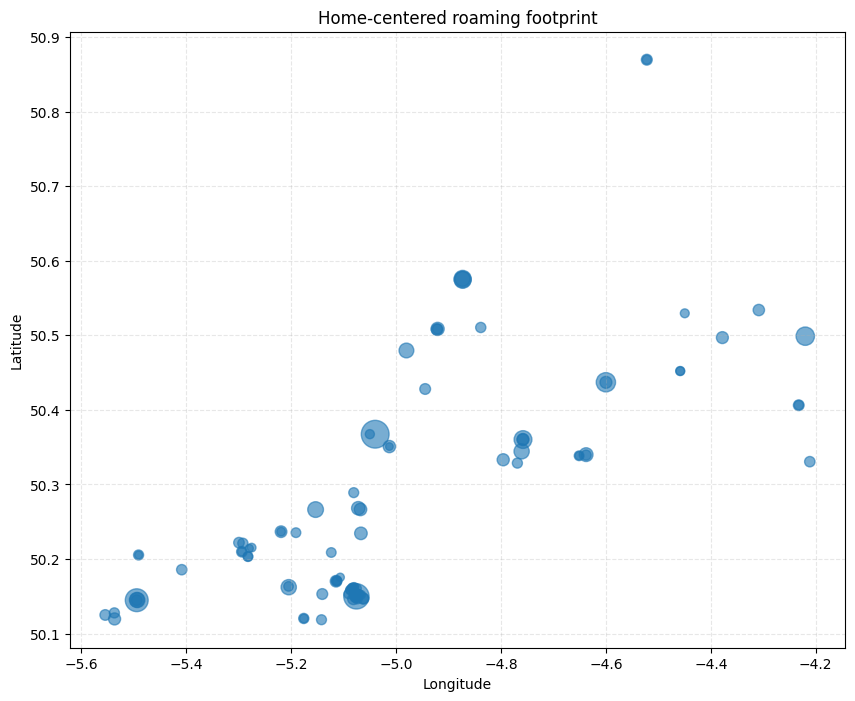

In [52]:
# Plot 1 : Home-centered roaming scale

# 1. To makes size comparisons easier, we min-max scale radius95_km to [0, 1] so the smallest cat becomes 0 and the largest becomes 1
r = cat_footprint["radius95_km"]
r_scaled = (r - r.min()) / (r.max() - r.min())

# 2. Map scaled values to a wider size range
sizes = 30 + r_scaled * 370

# 3. Plot each cat's home location with the scaled dot sizes
plt.figure(figsize=(10, 8))
plt.scatter(
    cat_footprint["home_long"],
    cat_footprint["home_lat"],
    s=sizes,
    alpha=0.6
)
plt.title("Home-centered roaming footprint")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


The map shows that home locations cluster into a few geographic pockets rather than being evenly distributed, suggesting that the cats originate from a limited number of neighborhoods or study areas. Within these pockets, the variation in dot sizes is substantial; some cats exhibit very small home-centered footprints, while others display significantly larger ones. Therefore, the scale of roaming is not solely determined by residential location. This combination of shared home areas and divergent roaming footprints suggests the presence of meaningful individual-level differences in movement behavior among cats living nearby.

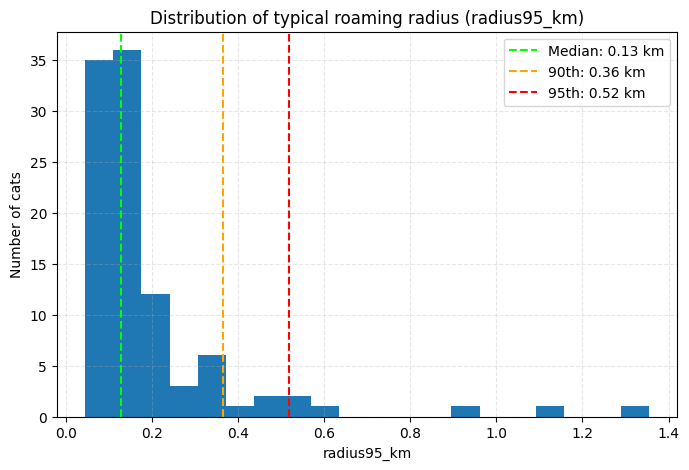

In [62]:
# Plot 2 : Roaming inequality and extreme roamers

# 1. Plot distribution of radius95_km across cats (typical roaming radius)
r = cat_footprint["radius95_km"].dropna()

# 2. Add reference lines to summarize the center and tail behavior
median_r = np.percentile(r, 50)
p90_r = np.percentile(r, 90)
p95_r = np.percentile(r, 95)

plt.figure(figsize=(8, 5))
plt.hist(r, bins=20)
plt.title("Distribution of typical roaming radius (radius95_km)")
plt.xlabel("radius95_km")
plt.ylabel("Number of cats")
plt.grid(True, linestyle="--", alpha=0.3)

plt.axvline(median_r, color="lime", linewidth=1.5, linestyle="--", label="Median: {:.2f} km".format(median_r))
plt.axvline(p90_r, color="orange", linewidth=1.5, linestyle="--", label="90th: {:.2f} km".format(p90_r))
plt.axvline(p95_r, color="red", linewidth=1.5, linestyle="--", label="95th: {:.2f} km".format(p95_r))

plt.legend(loc="upper right")
plt.show()

The histogram reveals a strongly right-skewed distribution of typical roaming radius. Most cats exhibit small roaming ranges, with the median around 0.13 km, indicating that the typical cat remains close to home. The upper tail of the distribution is substantial: the 90th percentile is already ~0.36 km and the 95th percentile reaches 0.52 km, with a few individuals roaming considerably farther. This pronounced gap between the central tendency and the upper tail suggests that roaming behavior is unequal. These outlier cases are notable because they can disproportionately influence average values and may reflect meaningful behavioral or environmental differences, such as outdoor access, hunting tendencies, or local context.

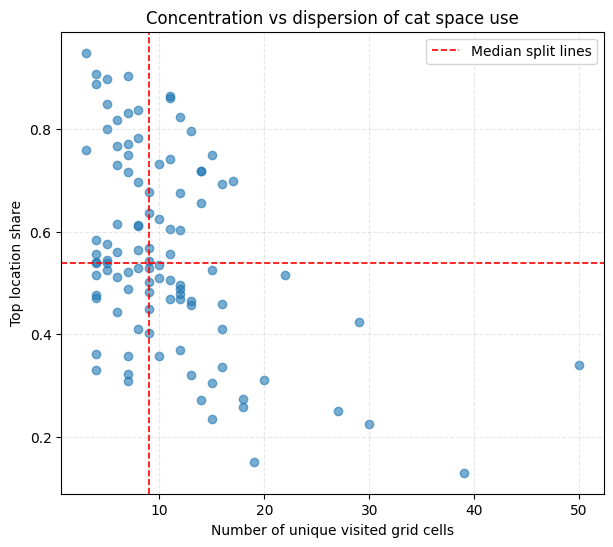

In [79]:
# Plot 3 : Concentration vs dispersion of cat space use

# 1. Scatter plot where each dot is one cat
# 2. unique_cells = how many areas visited; top1_share = how concentrated the cat is in its top area
x = cat_conc["unique_cells"]
y = cat_conc["top1_share"]

x_med = x.median()
y_med = y.median()

plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6)

plt.axvline(x_med, color="red", linewidth=1.2, linestyle="--")
plt.axhline(y_med, color="red", linewidth=1.2, linestyle="--")

plt.title("Concentration vs dispersion of cat space use")
plt.xlabel("Number of unique visited grid cells")
plt.ylabel("Top location share")
plt.grid(True, linestyle="--", alpha=0.3)

# 3. Add a legend for the red median lines
from matplotlib.lines import Line2D
legend_line = Line2D([0], [0], color="red", linewidth=1.2, linestyle="--", label="Median split lines")
plt.legend(handles=[legend_line], loc="upper right")
plt.show()

The scatter plot compares dispersion, defined as the number of distinct grid cells a cat visits, with concentration, measured by the dominance of the cat’s most-visited cell. Red median lines split the plot into four sections to help spot movement patterns. Most cats are grouped on the left, meaning they visit only a few areas and often return to the same spots. In this group, the the top location share varies a lot, from moderate to very high, suggesting that even cats with similar ranges may spend their time differently. A small subset of cats are high-dispersion outliers, typically located on the far right of the plot and generally exhibiting lower top location share, which may indicate an 'explorer' subgroup. Overall, the plot demonstrates a wide range of space-use behaviors and suggests more research is needed to understand what separates cats that stay close to home from those that roam more widely.

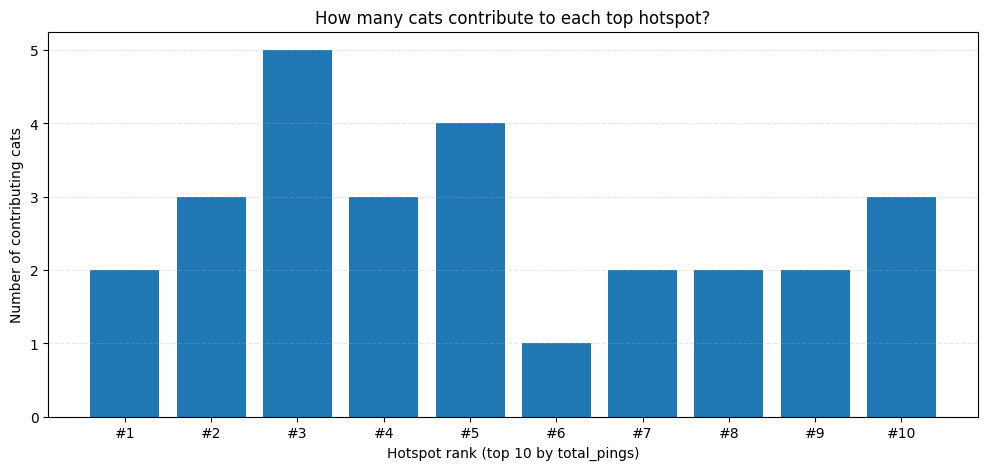

         grid_cell  unique_cats  total_pings
362   50.21_-5.294            2          804
768  50.508_-4.921            3          448
145  50.151_-5.077            5          393
775  50.509_-4.921            3          366
81   50.145_-5.494            4          361
500  50.329_-4.769            1          360
669    50.437_-4.6            2          348
711  50.452_-4.458            2          328
414  50.237_-5.219            2          302
629   50.36_-4.758            3          259


In [83]:
# Plot 4 : How many cats contribute to each top hotspot?

# 1. Focus on the top hotspot cells
# 2. Plot unique_cats only to show how many different cats contribute to each hotspot rank
x = np.arange(hotspot_top.shape[0])

plt.figure(figsize=(12, 5))
plt.bar(x, hotspot_top["unique_cats"])

plt.title("How many cats contribute to each top hotspot?")
plt.xlabel("Hotspot rank (top 10 by total_pings)")
plt.ylabel("Number of contributing cats")
plt.xticks(x, ["#{}".format(i+1) for i in range(hotspot_top.shape[0])])
plt.grid(True, axis="y", linestyle="--", alpha=0.3)
plt.show()

# 3. Print the hotspot table for quick inspection
print(hotspot_top[["grid_cell", "unique_cats", "total_pings"]])

Among the top 10 hotspot cells ranked by total_pings, the number of contributing cats (unique_cats) is generally low. Most hotspot cells are driven by only 1–3 cats, suggesting that high activity often reflects repeated visits from a small set of individuals rather than broadly shared public areas. However, a few hotspots (e.g., ranks #3 and #5) are supported by more cats, indicating that even within the most active cells, there may be both “individual-driven” hotspots and more “shared” hotspots.